### Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load all csv files

In [2]:
crimes = pd.read_csv("Crimes.csv")
victims = pd.read_csv("Victims.csv")
locations = pd.read_csv("Locations.csv")
police = pd.read_csv("Police_Stations.csv")
cases = pd.read_csv("Cases.csv")

### Basic Exploration

In [3]:
crimes.head()

crimes.info()

crimes.describe()

crimes.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   crime_id     5000 non-null   object
 1   victim_id    5000 non-null   object
 2   location_id  5000 non-null   object
 3   station_id   5000 non-null   object
 4   crime_type   5000 non-null   object
 5   crime_date   5000 non-null   object
 6   crime_time   5000 non-null   object
 7   severity     5000 non-null   object
 8   weapon_used  2504 non-null   object
 9   loss_amount  5000 non-null   int64 
 10  arrest_made  5000 non-null   object
dtypes: int64(1), object(10)
memory usage: 429.8+ KB


(5000, 11)

### Missing & Duplicate Value Analysis

In [28]:
crimes.isnull().sum()
crimes.duplicated().sum()

np.int64(0)

### Merge Tables

In [6]:
crime_data = crimes.merge(
    victims,
    on="victim_id",
    how="left"
)

### Loss analysis

In [30]:
avg_loss = np.mean(crimes['loss_amount'])
print("avg_loss= ",avg_loss)
max_loss = np.max(crimes['loss_amount'])
print("max_loss= ",max_loss)
std_loss = np.std(crimes['loss_amount'])
print("std_loss= ",std_loss)

avg_loss=  251594.632
max_loss=  499784
std_loss=  145012.1339600689


In [31]:
# Crime Type Distribution
crimes['crime_type'].value_counts()

crime_type
Robbery        778
Cyber Crime    750
Burglary       741
Kidnapping     701
Assault        697
Theft          683
Fraud          650
Name: count, dtype: int64

In [32]:
#vArrest Rate
crimes['arrest_made'].value_counts(normalize=True)*100

arrest_made
Yes    64.32
No     35.68
Name: proportion, dtype: float64

In [33]:
# Severity Distribution
crimes['severity'].value_counts()

severity
Low       2011
Medium    2006
High       983
Name: count, dtype: int64

<Axes: xlabel='crime_type', ylabel='count'>

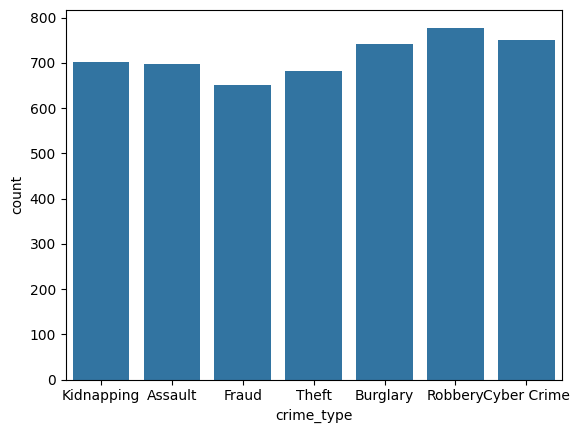

In [34]:
# Crime Type Count
sns.countplot(data=crimes,x='crime_type')

<Axes: xlabel='severity', ylabel='count'>

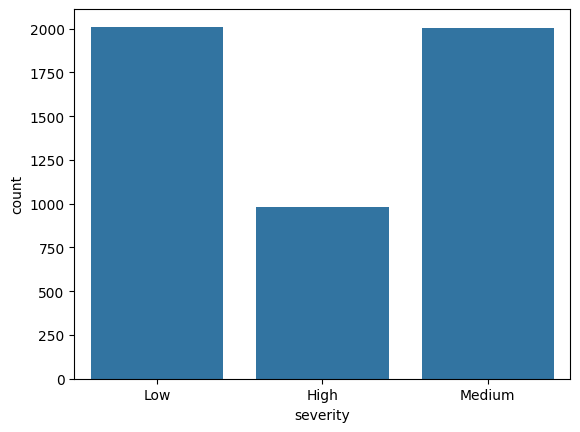

In [35]:
# Severity Distribution
sns.countplot(data=crimes,x='severity')

<Axes: ylabel='count'>

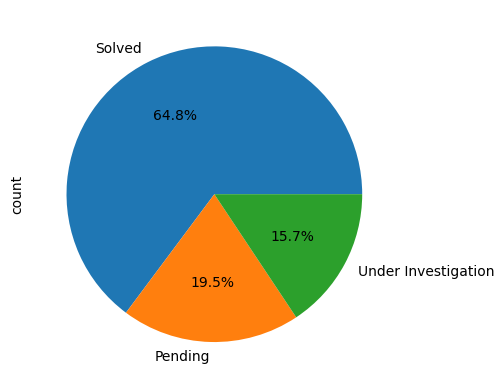

In [36]:
# Case Status Pie Chart
cases['case_status'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

city
Jaipur       734
Delhi        700
Surat        691
Rajkot       674
Vadodara     610
Mumbai       606
Pune         523
Ahmedabad    462
Name: count, dtype: int64


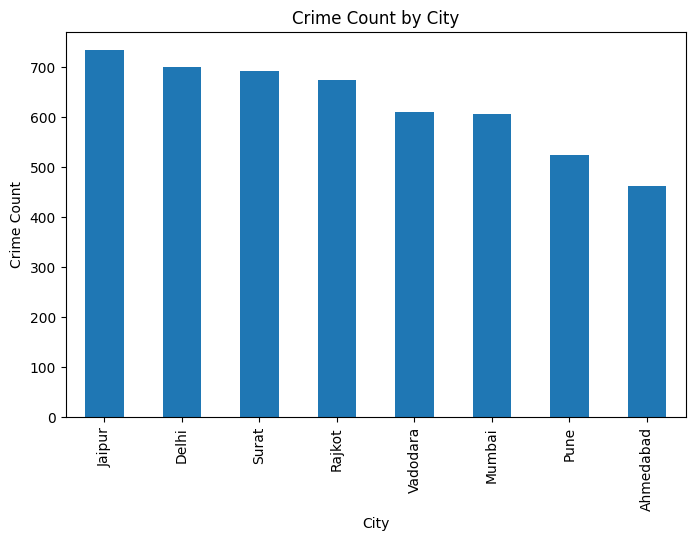

In [37]:
# Top Cities by Crime Count
city_crimes = crimes.merge(
    locations[['location_id','city']],
    on='location_id'
)

city_crime_count = city_crimes['city'].value_counts()

print(city_crime_count)

plt.figure(figsize=(8,5))

city_crime_count.plot(kind='bar')

plt.title('Crime Count by City')
plt.xlabel('City')
plt.ylabel('Crime Count')

plt.show()

arrest_made
Yes    3216
No     1784
Name: count, dtype: int64


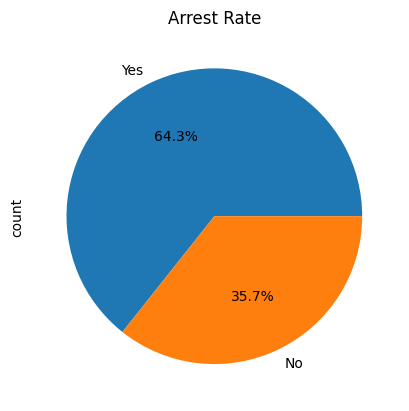

In [38]:
# Arrest Rate Analysis
arrest_rate = crimes['arrest_made'].value_counts()

print(arrest_rate)

arrest_rate.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Arrest Rate')

plt.show()

weapon_used
Knife    1274
Gun       724
Stick     506
Name: count, dtype: int64


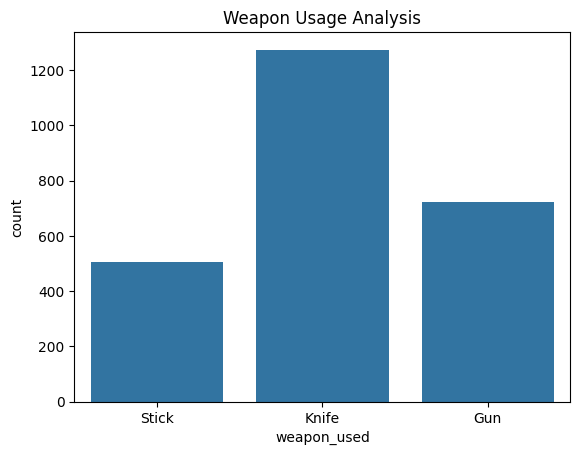

In [39]:
# Weapon Used Analysis
weapon_count = crimes['weapon_used'].value_counts()

print(weapon_count)

sns.countplot(
    data=crimes,
    x='weapon_used'
)

plt.title('Weapon Usage Analysis')

plt.show()

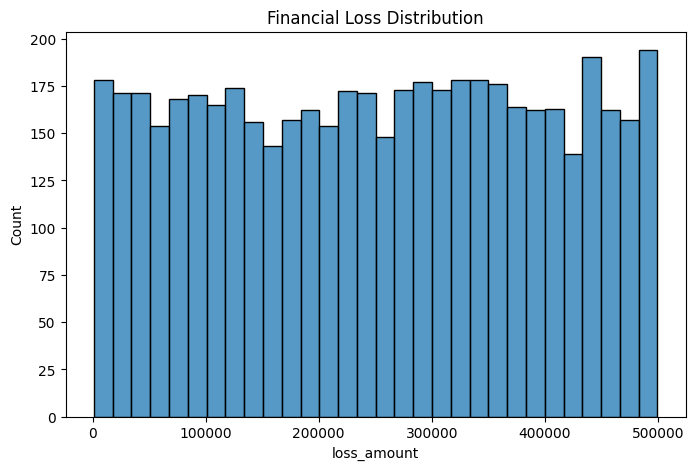

In [40]:
# Loss Amount Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    crimes['loss_amount'],
    bins=30
)

plt.title('Financial Loss Distribution')

plt.show()


crime_type
Assault        248907.045911
Burglary       252696.358974
Cyber Crime    254129.961333
Fraud          253397.169231
Kidnapping     247649.339515
Robbery        252371.580977
Theft          251806.792094
Name: loss_amount, dtype: float64


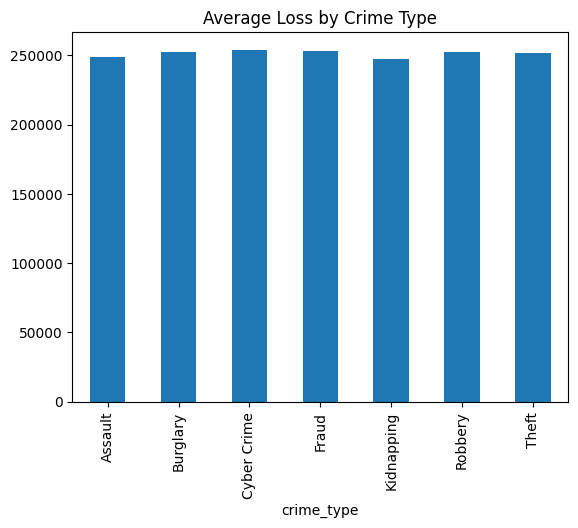

In [41]:
# Average Loss by Crime Type
avg_loss = crimes.groupby(
    'crime_type'
)['loss_amount'].mean()

print(avg_loss)

avg_loss.plot(
    kind='bar'
)

plt.title('Average Loss by Crime Type')

plt.show()

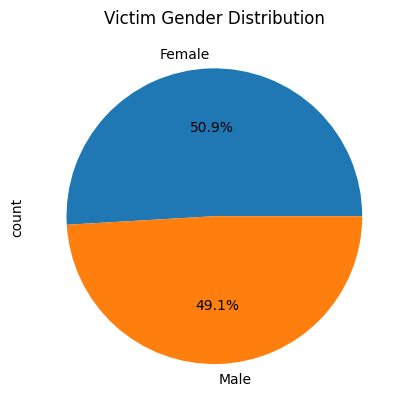

In [43]:
# Victim Gender Analysis
victims['gender'].value_counts()

victims['gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Victim Gender Distribution')

plt.show()

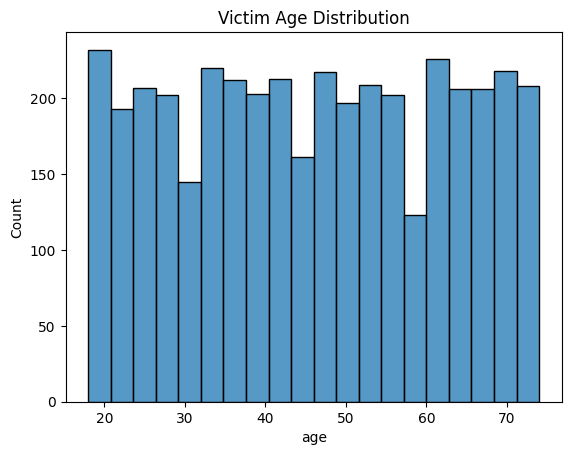

In [44]:
# Victim Age Analysis
sns.histplot(
    victims['age'],
    bins=20
)

plt.title('Victim Age Distribution')

plt.show()

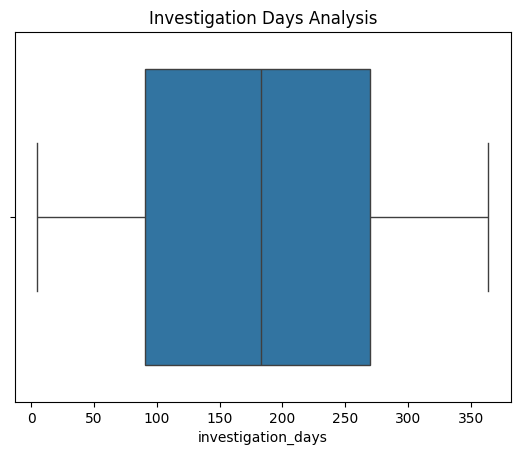

In [46]:
# Investigation Days Analysis
cases['investigation_days'].describe()

sns.boxplot(
    x=cases['investigation_days']
)

plt.title('Investigation Days Analysis')

plt.show()

In [47]:
# KPIS
print("Total Crimes :", len(crimes))

print("Total Victims :", len(victims))

print("Total Cases :", len(cases))

print("Highest Crime Type :",
      crimes['crime_type'].value_counts().idxmax())

print("Most Common Severity :",
      crimes['severity'].value_counts().idxmax())

print("Average Financial Loss :",
      round(crimes['loss_amount'].mean(),2))

print("Arrest Rate :",
      round(
          (crimes['arrest_made']=="Yes").mean()*100,
          2
      ),
      "%"
)

Total Crimes : 5000
Total Victims : 4000
Total Cases : 5000
Highest Crime Type : Robbery
Most Common Severity : Low
Average Financial Loss : 251594.63
Arrest Rate : 64.32 %


In [48]:
# Export Final Dataset
final_data = crimes.merge(
    victims,
    on='victim_id',
    how='left'
)

final_data = final_data.merge(
    locations,
    on='location_id',
    how='left'
)

final_data = final_data.merge(
    cases,
    on='crime_id',
    how='left'
)

final_data.to_csv(
    'Crime_Analytics_Final.csv',
    index=False
)

In [49]:
final_data.head()

,crime_id,victim_id,location_id,station_id,crime_type,crime_date,crime_time,severity,weapon_used,loss_amount,...,state,zone,risk_level,population_category,case_id,case_status,investigation_days,fine_amount,court_status,case_priority
0,C000001,V02996,L0185,S036,Kidnapping,2023-01-15,Evening,Low,Stick,11486,...,Maharashtra,South,Medium,High,CASE000001,Solved,275,15329,Ongoing,High
1,C000002,V01278,L0221,S055,Kidnapping,2025-02-24,Night,High,NaN,128275,...,Gujarat,Central,Low,High,CASE000002,Pending,29,74887,Ongoing,High
2,C000003,V01144,L0104,S042,Assault,2023-04-17,Morning,Medium,Knife,175248,...,Maharashtra,East,Medium,Low,CASE000003,Solved,274,84340,Closed,Medium
3,C000004,V00032,L0243,S006,Assault,2024-01-30,Evening,Low,Knife,471235,...,Gujarat,West,Low,High,CASE000004,Solved,127,85532,Hearing,Medium
4,C000005,V03777,L0045,S005,Assault,2023-04-14,Evening,Low,Stick,50314,...,Gujarat,Central,Low,High,CASE000005,Pending,239,30043,Hearing,Low


In [50]:
final_data.isnull().sum()

crime_id                  0
victim_id                 0
location_id               0
station_id                0
crime_type                0
crime_date                0
crime_time                0
severity                  0
weapon_used            2496
loss_amount               0
arrest_made               0
victim_name               0
gender                    0
age                       0
occupation                0
marital_status            0
income_group              0
city                      0
state                     0
zone                      0
risk_level                0
population_category       0
case_id                   0
case_status               0
investigation_days        0
fine_amount               0
court_status              0
case_priority             0
dtype: int64

In [51]:
final_data['weapon_used'] = final_data['weapon_used'].fillna('Unknown')

In [52]:
final_data.duplicated().sum()

np.int64(0)

In [53]:
final_data.to_csv(
    "Crime_Analytics_Final.csv",
    index=False
)

In [54]:
final_data.isnull().sum()

final_data.duplicated().sum()

np.int64(0)